# Rede Neural do Zero — Demo MNIST

Demonstração de uma MLP implementada manualmente com NumPy puro, treinada no dataset MNIST (dígitos manuscritos 0–9).

**Stack:** Python 3.11+ · NumPy · Matplotlib  
**Proibido:** scikit-learn, PyTorch, TensorFlow, Keras

## 1. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import gzip
import struct
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from src.activations import relu, relu_derivada, softmax
from src.layers import Layer
from src.losses import cross_entropy, cross_entropy_derivada
from src.network import Network
from src.utils import normalizar, one_hot, dividir

## 2. Download e carregamento do MNIST

Os arquivos são baixados do repositório oficial no formato IDX binário e lidos manualmente — sem bibliotecas de ML.

In [2]:
PASTA_DADOS = Path('../data/mnist')
PASTA_DADOS.mkdir(parents=True, exist_ok=True)

ARQUIVOS = {
    'train_imgs': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz',
    'train_lbls': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz',
    'test_imgs':  'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz',
    'test_lbls':  'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz',
}

def _baixar(url: str, destino: Path) -> None:
    """Baixa o arquivo se ainda não existir."""
    if not destino.exists():
        print(f'Baixando {destino.name}...')
        urllib.request.urlretrieve(url, destino)

def _ler_imagens(caminho: Path) -> np.ndarray:
    """Lê arquivo IDX de imagens e retorna array (n, 784)."""
    with gzip.open(caminho, 'rb') as f:
        magic, n, h, w = struct.unpack('>IIII', f.read(16))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, h * w)

def _ler_labels(caminho: Path) -> np.ndarray:
    """Lê arquivo IDX de rótulos e retorna vetor (n,)."""
    with gzip.open(caminho, 'rb') as f:
        magic, n = struct.unpack('>II', f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)

# Download
for nome, url in ARQUIVOS.items():
    _baixar(url, PASTA_DADOS / f'{nome}.gz')

# Leitura
X_treino_raw = _ler_imagens(PASTA_DADOS / 'train_imgs.gz')
y_treino_raw = _ler_labels(PASTA_DADOS / 'train_lbls.gz')
X_teste_raw  = _ler_imagens(PASTA_DADOS / 'test_imgs.gz')
y_teste_raw  = _ler_labels(PASTA_DADOS / 'test_lbls.gz')

print(f'Treino: {X_treino_raw.shape} | Teste: {X_teste_raw.shape}')

Baixando train_imgs.gz...
Baixando train_lbls.gz...
Baixando test_imgs.gz...
Baixando test_lbls.gz...
Treino: (60000, 784) | Teste: (10000, 784)


## 3. Pré-processamento

In [3]:
# Normalização: pixels [0, 255] → média 0, desvio 1
X_treino = normalizar(X_treino_raw.astype(float))
X_teste  = normalizar(X_teste_raw.astype(float))

# Rótulos inteiros → one-hot
y_treino = one_hot(y_treino_raw, n_classes=10)
y_teste  = one_hot(y_teste_raw,  n_classes=10)

# Subconjunto de validação a partir do treino
X_tr, X_val, y_tr, y_val = dividir(X_treino, y_treino, proporcao_treino=0.9, semente=42)

print(f'Treino: {X_tr.shape} | Validação: {X_val.shape} | Teste: {X_teste.shape}')

Treino: (54000, 784) | Validação: (6000, 784) | Teste: (10000, 784)


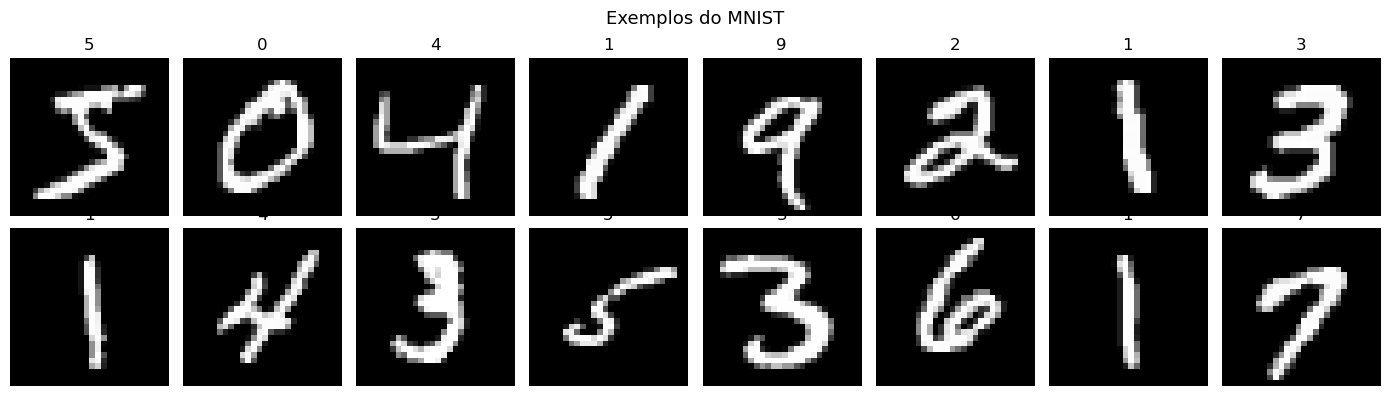

In [4]:
# Visualização de exemplos do conjunto de treino
fig, eixos = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(eixos.flat):
    ax.imshow(X_treino_raw[i].reshape(28, 28), cmap='gray')
    ax.set_title(str(y_treino_raw[i]))
    ax.axis('off')
plt.suptitle('Exemplos do MNIST', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Construção da rede

Arquitetura: **784 → 128 (ReLU) → 64 (ReLU) → 10 (Softmax)**

In [5]:
np.random.seed(42)

rede = Network([
    Layer(784, 128, relu, relu_derivada),
    Layer(128,  64, relu, relu_derivada),
    Layer( 64,  10, softmax, ativacao_derivada=None),
])

print('Camadas:')
for i, c in enumerate(rede.camadas):
    print(f'  [{i}] W={c.W.shape}  b={c.b.shape}  ativação={c.ativacao.__name__}')

Camadas:
  [0] W=(784, 128)  b=(1, 128)  ativação=relu
  [1] W=(128, 64)  b=(1, 64)  ativação=relu
  [2] W=(64, 10)  b=(1, 10)  ativação=softmax


## 5. Treinamento

In [6]:
EPOCHS          = 20
TAXA_APRENDIZADO = 0.01
TAMANHO_LOTE    = 64

historico = rede.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    taxa_aprendizado=TAXA_APRENDIZADO,
    funcao_custo=cross_entropy,
    funcao_custo_derivada=cross_entropy_derivada,
    tamanho_lote=TAMANHO_LOTE,
    verbose=True,
)

Época    1/20 — loss: 0.622402
Época    2/20 — loss: 0.262450
Época    4/20 — loss: 0.170011
Época    6/20 — loss: 0.130584
Época    8/20 — loss: 0.106527
Época   10/20 — loss: 0.089348
Época   12/20 — loss: 0.076602
Época   14/20 — loss: 0.065653
Época   16/20 — loss: 0.057515
Época   18/20 — loss: 0.050539
Época   20/20 — loss: 0.044754


## 6. Curva de loss

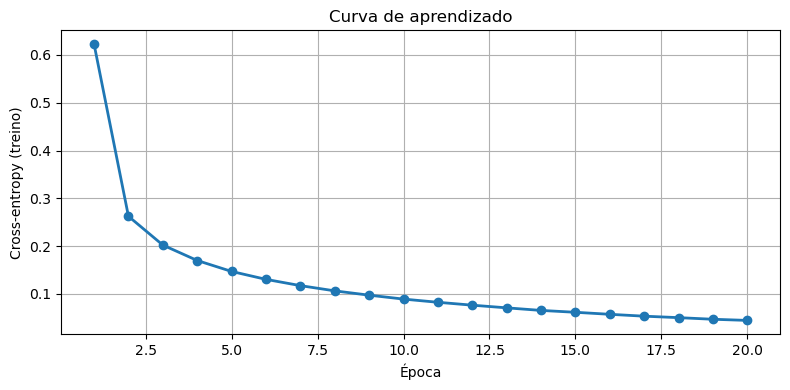

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), historico, marker='o', linewidth=2)
plt.xlabel('Época')
plt.ylabel('Cross-entropy (treino)')
plt.title('Curva de aprendizado')
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Avaliação

In [8]:
loss_val, acc_val   = rede.evaluate(X_val,   y_val,   cross_entropy)
loss_test, acc_test = rede.evaluate(X_teste,  y_teste,  cross_entropy)

print(f'Validação — loss: {loss_val:.4f}  |  acurácia: {acc_val*100:.2f}%')
print(f'Teste     — loss: {loss_test:.4f}  |  acurácia: {acc_test*100:.2f}%')

Validação — loss: 0.1413  |  acurácia: 96.52%
Teste     — loss: 0.1269  |  acurácia: 96.70%


## 8. Exemplos de predição

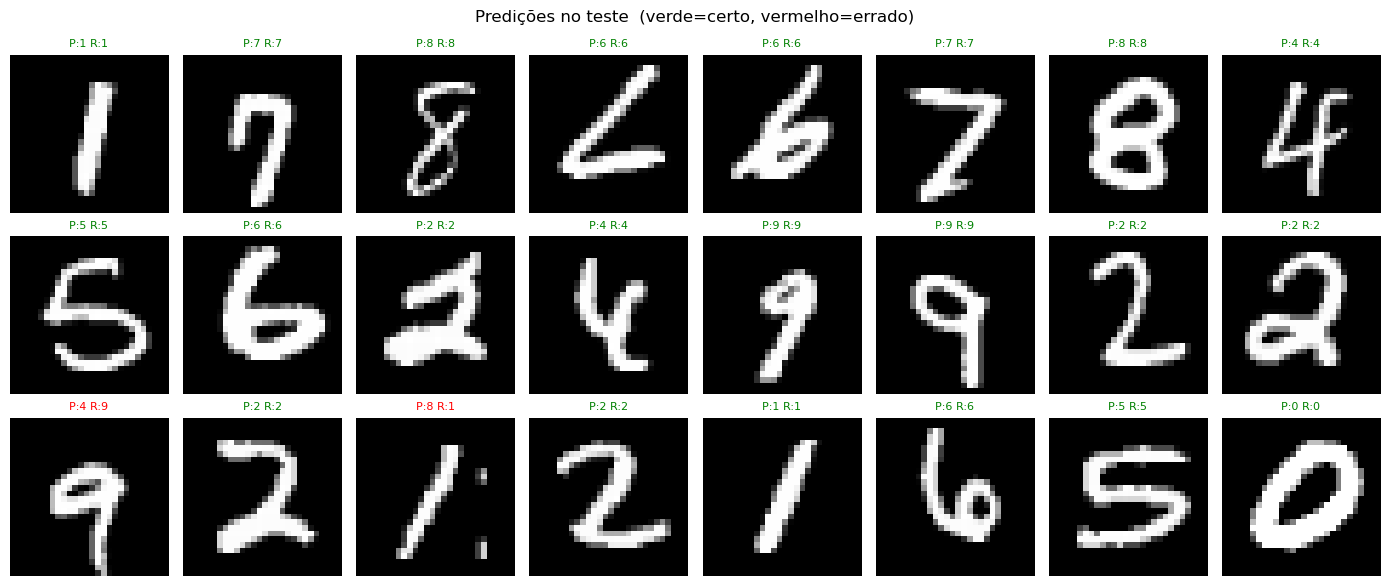

In [9]:
y_pred_teste = rede.predict(X_teste)
classes_pred = np.argmax(y_pred_teste, axis=1)
classes_real = y_teste_raw

fig, eixos = plt.subplots(3, 8, figsize=(14, 6))
indices = np.random.choice(len(X_teste_raw), 24, replace=False)

for ax, idx in zip(eixos.flat, indices):
    correto = classes_pred[idx] == classes_real[idx]
    cor = 'green' if correto else 'red'
    ax.imshow(X_teste_raw[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'P:{classes_pred[idx]} R:{classes_real[idx]}', color=cor, fontsize=8)
    ax.axis('off')

plt.suptitle('Predições no teste  (verde=certo, vermelho=errado)', fontsize=12)
plt.tight_layout()
plt.show()